In [2]:
# !pip install --upgrade jax

!pip install -U "jax[cuda12]"
# !pip install -U flax optax numpy functools matplotlib
# !uv pip install numpy --upgrade # needed for dataset construction to not raise an error

Looking in indexes: http://mirrors.aliyun.com/pypi/simple


In [4]:
import jax
import jax.numpy as jnp
from jax import lax, grad, random
from jax.sharding import PartitionSpec as P

from flax import struct
import optax

import math
import numpy as np
from functools import partial
import matplotlib.pyplot as plt

In [5]:
# jax.config.update("jax_num_cpu_devices", 8) # simulate 8 devices -> disable later

jax.devices()

[CudaDevice(id=0)]

In [6]:
# X, Y = 8, 1
# X, Y = 2, 1 # using GPUs
X, Y = 1, 1

Explicit = jax.sharding.AxisType.Explicit

mesh = jax.make_mesh((X, Y), ('X', 'Y'), (Explicit, Explicit)) # default Explicit
jax.set_mesh(mesh)

## Building the model (MoE)

In [7]:
@struct.dataclass
class Config:
    n_layers: jnp.int32

    d_model: jnp.int32
    d_ff: jnp.int32

    n_heads: jnp.int32
    n_kv_heads: jnp.int32
    d_qkv: jnp.int32

    n_experts: jnp.int32
    n_active: jnp.int32
    
    n_embed: jnp.int32
    max_seq_len: jnp.int32
    
    dtype: jnp.dtype = jnp.bfloat16
    param_dtype: jnp.dtype = jnp.float32

In [8]:
def init_params(cfg: Config, rng: random.key) -> dict:
    
    embed_key, unembed_key, rng = random.split(rng, 3)

    params = {}
    
    params["W_embed"] = random.normal(embed_key, (cfg.n_embed, cfg.d_model), dtype=cfg.param_dtype) * 0.02
    params["W_unembed"] = random.normal(unembed_key, (cfg.d_model, cfg.n_embed), dtype=cfg.param_dtype) * 0.02

    initializer = jax.nn.initializers.glorot_normal()
    initializer_attn = jax.nn.initializers.glorot_normal(in_axis=0, out_axis=(1, 2))
    initializer_proj = jax.nn.initializers.glorot_normal(in_axis=(0, 1), out_axis=2)
    initializer_ffw = jax.nn.initializers.glorot_normal(in_axis=1, out_axis=2)
    
    params["layers"] = []
    for i in range(cfg.n_layers):
        layer_params = {}
        
        q_key, k_key, v_key, o_key, route_key, in_key, out_key, rng = random.split(rng, 8)
        
        layer_params["W_q"] = initializer_attn(q_key, (cfg.d_model, cfg.n_heads, cfg.d_qkv), dtype=cfg.param_dtype)
        layer_params["W_k"] = initializer_attn(k_key, (cfg.d_model, cfg.n_kv_heads, cfg.d_qkv), dtype=cfg.param_dtype)
        layer_params["W_v"] = initializer_attn(v_key, (cfg.d_model, cfg.n_kv_heads, cfg.d_qkv), dtype=cfg.param_dtype)
        
        layer_params["W_o"] = initializer_proj(o_key, (cfg.n_heads, cfg.d_qkv, cfg.d_model), dtype=cfg.param_dtype)

        layer_params["W_r"] = initializer(route_key, (cfg.d_model, cfg.n_experts), dtype=cfg.param_dtype)
        
        layer_params["W_in"] = initializer_ffw(in_key, (cfg.n_experts, cfg.d_model, cfg.d_ff), dtype=cfg.param_dtype)
        layer_params["W_out"] = initializer_ffw(out_key, (cfg.n_experts, cfg.d_ff, cfg.d_model), dtype=cfg.param_dtype)

        layer_params["gamma1"] = jnp.ones((cfg.d_model, ), dtype=cfg.param_dtype)
        layer_params["beta1"] = jnp.zeros((cfg.d_model, ), dtype=cfg.param_dtype)

        layer_params["gamma2"] = jnp.ones((cfg.d_model, ), dtype=cfg.param_dtype)
        layer_params["beta2"] = jnp.zeros((cfg.d_model, ), dtype=cfg.param_dtype)

        params["layers"].append(layer_params)

    # final LN

    params["gamma"] = jnp.ones((cfg.d_model, ), dtype=cfg.param_dtype)
    params["beta"] = jnp.zeros((cfg.d_model, ), dtype=cfg.param_dtype)
    
    return params

In [9]:
def RoPE(x: jnp.array) -> jnp.array:

    H = x.shape[-1]
    T = x.shape[1]
    
    assert H % 2 == 0

    base = 10000
    exp = -2 * jnp.arange(H//2, dtype=x.dtype) / H
    theta = jnp.arange(T).reshape(T, 1) * jnp.float_power(base, exp)

    cos_vec = jnp.cos(theta).reshape(1, T, 1, H//2)
    sin_vec = jnp.sin(theta).reshape(1, T, 1, H//2)

    x1, x2 = jnp.split(x, 2, axis=-1)

    x1_new = x1 * cos_vec - x2 * sin_vec
    x2_new = x1 * sin_vec + x2 * cos_vec

    return jnp.concatenate([x1_new, x2_new], axis=-1, dtype=x.dtype)

In [10]:
def attention(x: jnp.array, W_q: jnp.array, W_k: jnp.array, W_v: jnp.array, W_o: jnp.array, attn_mask: jnp.array = None, is_causal: bool = True) -> jnp.array:

    B = x.shape[0]
    T = x.shape[1] # assume T == S
    
    N = W_q.shape[1]
    K = W_k.shape[1]
    H = W_q.shape[-1]

    assert N % K == 0

    W_q = W_q.astype(x.dtype)
    W_k = W_k.astype(x.dtype)
    W_v = W_v.astype(x.dtype)
    W_o = W_o.astype(x.dtype)
    
    
    q = jnp.einsum('btd,dnh->btnh', x, W_q)
    k = jnp.einsum('bsd,dnh->bsnh', x, W_k)
    v = jnp.einsum('bsd,dnh->bsnh', x, W_v)

    q = RoPE(q)
    k = RoPE(k)

    q = q.reshape((B, T, K, -1, H))

    s = jnp.einsum('btkgh,bskh->btskg', q, k)

    s /= jnp.sqrt(H)
    
    if (attn_mask is not None or is_causal): 
    
        mask = jnp.ones((B, T, T), dtype=x.dtype)

        if (is_causal):
            mask = jnp.tril(mask)
        
        if (attn_mask is not None):
            mask = mask * attn_mask.reshape((B, -1, T))

        mask = mask.reshape((B, T, T, 1, 1))
        
        s = jnp.where(mask, s, -jnp.inf)

    # s = jnp.exp(s) / jnp.sum(jnp.exp(s), axis=2, keepdims=True) # softmax
    s = jax.nn.softmax(s, axis=2)

    a = jnp.einsum('btskg,bskh->btkgh', s, v)
    a = a.reshape((B, T, N, H))

    out = jnp.einsum('btnh,nhd->btd', a, W_o)
    return out

In [11]:
@jax.custom_vjp
def ragged_dot(x, W, g):
    return lax.ragged_dot(x, W, g)

def ragged_dot_fwd(x, W, g):
    return ragged_dot(x, W, g), (x, W, g)

def ragged_dot_bwd(carrys, dOut):
    x, W, g = carrys

    dx = lax.ragged_dot(dOut, jnp.transpose(W, (0,2,1)), g)
    
    dW = lax.ragged_dot_general(
        x, dOut, g,
        lax.RaggedDotDimensionNumbers(
            (([0], [0]), ([], [])),
            [0],
            []
        )
    )

    dW = lax.psum(dW, 'X')
    
    return dx, dW, None

ragged_dot.defvjp(ragged_dot_fwd, ragged_dot_bwd)

In [12]:
def mlp(x: jnp.array, W_r: jnp.array, k: jnp.int32, W_in: jnp.array, W_out: jnp.array) -> jnp.array:
    
    B = x.shape[0]
    T = x.shape[1]
    D = x.shape[2]
    E = W_in.shape[0]

    
    @jax.shard_map(
        in_specs=(P('X'), P('X', None), P(None, None, None), P(None, None, None)),
        out_specs=P('X', None)
    )
    def local_ragged_dot(idx, x, W_in, W_out): 
        perm = jnp.argsort(idx)
        x_sorted = x[perm]
    
        group_sizes = jnp.bincount(idx, length=E)
        tmp = ragged_dot(x_sorted, W_in, group_sizes)
        act = jax.nn.gelu(tmp)
        
        out_sorted = ragged_dot(act, W_out, group_sizes)
        perm_inv = jnp.argsort(perm)    
        out = out_sorted[perm_inv]
        
        return out

    
    W_r = W_r.astype(x.dtype) # consider if needed later
    W_in = W_in.astype(x.dtype)
    W_out = W_out.astype(x.dtype)
    
    routing = jnp.einsum('btd,de->bte', x, W_r)
    routing = jax.nn.softmax(routing) # in case we end up with 0
    
    gate, idx = lax.top_k(routing, k)

    gate = gate / gate.sum(axis=-1, keepdims=True, dtype=jnp.float32) # temporarily set as float32 for greater precision
    gate = gate.astype(x.dtype)
    
    idx_flat = idx.flatten()
    
    x_repeat = jnp.repeat(x, k, axis=1)
    x_repeat = x_repeat.reshape((-1, D))

    out_repeat = local_ragged_dot(idx_flat, x_repeat, W_in, W_out)
    out_repeat = out_repeat.reshape((B, T, -1, D))

    out = jnp.einsum('btkd,btk->btd', out_repeat, gate)

    return out

In [13]:
def layerNorm(x: jnp.array, gamma: jnp.array, beta: jnp.array) -> jnp.array:

    mu = jnp.mean(x, axis=-1, keepdims=True)
    var = jnp.var(x, axis=-1, keepdims=True)

    epsilon = 1e-5
    tmp = (x - mu) / jnp.sqrt(var + epsilon)

    out = gamma * tmp + beta
    
    return out.astype(x.dtype)

In [14]:
def transformer_block(layer_params: optax.Params, x: jnp.array, k: jnp.int32, attn_mask: jnp.array = None) -> jnp.array:

    # pre-norm
    
    gamma1 = layer_params["gamma1"]
    beta1 = layer_params["beta1"]
    
    x_norm = layerNorm(x, gamma1, beta1)
    
    # attention
    
    W_q = layer_params["W_q"]
    W_k = layer_params["W_k"]
    W_v = layer_params["W_v"]
    W_o = layer_params["W_o"]
    
    attn_out = attention(x_norm, W_q, W_k, W_v, W_o, attn_mask=attn_mask, is_causal=True)

    attn_out = attn_out + x # residue connection

    # norm

    gamma2 = layer_params["gamma2"]
    beta2 = layer_params["beta2"]
    
    attn_norm = layerNorm(attn_out, gamma2, beta2)

    # mlp

    W_r = layer_params["W_r"]
    W_in = layer_params["W_in"]
    W_out = layer_params["W_out"]

    ffw_out = mlp(attn_norm, W_r, k, W_in, W_out)

    ffw_out = ffw_out + attn_out # residue connection
    
    return ffw_out

In [15]:
def forward(params: optax.Params, x: jnp.array, k: jnp.int32, attn_mask: jnp.array = None) -> jnp.array:

    W_embed = params["W_embed"].astype(x.dtype)
    
    x = jnp.einsum("btv,vd->btd", x, W_embed) # embedding

    
    for layer_params in params["layers"]:
        x = transformer_block(layer_params, x, k, attn_mask=attn_mask)

    gamma = params["gamma"]
    beta = params["beta"]
    
    x_norm = layerNorm(x, gamma, beta)
    
    W_unembed = params["W_unembed"].astype(x.dtype)
    
    out = jnp.einsum("btd,dv->btv", x_norm, W_unembed) # unembedding

    return out

## Building the dataset

3-digit addition

In [16]:
seq_len = 16


# all possible combinations

n_samples = 1000 * 1000

A1 = np.tile(np.arange(1000), 1000)
A2 = np.arange(1000).repeat(1000)

A = np.stack([A1, A2, A1+A2])


# select sample

# n_samples = 10000

# rng = np.random.default_rng()

# A1 = rng.integers(low=0, high=1000, size=n_samples)
# A2 = rng.integers(low=0, high=1000, size=n_samples)
# A = np.stack([A1, A2, A1+A2])

In [17]:
A_size = np.strings.str_len(A.astype(np.str_))

A = A[2] + A[1] * (10 ** (A_size[2]+3)) + A[0] * (10 ** (A_size[2]+A_size[1]+6))

# A_size_comb = np.strings.str_len(A.astype(np.str_)) # breaks for A[0]==0

A_size_comb = A_size.sum(axis=0) + 6

A = A * (10 ** (seq_len - A_size_comb))

In [18]:
X = np.zeros((n_samples, seq_len))

for i in range(seq_len):
    X[:, seq_len-i-1] = A % 10
    A //= 10

X.put(np.arange(n_samples)*16 + A_size[0] + 1, 11) # inserting addition signs

X.put(np.arange(n_samples)*16 + A_size[0] + A_size[1] + 4, 12) # inserting equal signs


attn_masks = np.where(np.indices((n_samples, seq_len))[1] < (A_size.sum(axis=0) + 6).reshape(n_samples, 1), 1, 0) # masks out the padding

loss_masks = np.where(np.indices((n_samples, seq_len))[1] < (A_size.sum(axis=0) + 5).reshape(n_samples, 1), 1, 0) # masks out padding + last position
loss_masks *= np.where(np.indices((n_samples, seq_len))[1] >= (A_size[0] + A_size[1] + 5).reshape(n_samples, 1), 1, 0) # masks out everything before ans (not including last space)

# inserting space signs
X.put(np.arange(n_samples)*16 + A_size[0], 10)
X.put(np.arange(n_samples)*16 + A_size[0] + 2, 10)
X.put(np.arange(n_samples)*16 + A_size[0] + A_size[1] + 3, 10) 
X.put(np.arange(n_samples)*16 + A_size[0] + A_size[1] + 5, 10) 

X += (1 - attn_masks) * 10 # set padding to space bars

In [19]:
Y = X[:, 1:]
Y = np.pad(Y, ((0,0), (0,1)), constant_values=10)

In [20]:
rng = np.random.default_rng(40)

perm = np.arange(n_samples)
rng.shuffle(perm)

X = X[perm]
Y = Y[perm]
attn_masks = attn_masks[perm]
loss_masks = loss_masks[perm]

In [21]:
X.shape, Y.shape

((1000000, 16), (1000000, 16))

In [22]:
print(X[0])
print(Y[0])
print(attn_masks[0])
print(loss_masks[0])

[ 5.  6.  9. 10. 11. 10.  5.  7.  5. 10. 12. 10.  1.  1.  4.  4.]
[ 6.  9. 10. 11. 10.  5.  7.  5. 10. 12. 10.  1.  1.  4.  4. 10.]
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
[0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 0]


## Training the model (pilot)

In [23]:
@partial(
    jax.jit,
    static_argnames=["optimizer", "k"]
)
def train_step(params: optax.Params, state: optax.Params, optimizer: optax.GradientTransformation, x: jnp.array, y: jnp.array, k: jnp.int32, attn_mask: jnp.array = None, loss_mask: jnp.array = None):

    def loss_fn(params: optax.Params):
        logits = forward(params, x, k, attn_mask)
        loss = optax.losses.softmax_cross_entropy(logits, y)

        if (loss_mask is not None):
            return (loss * loss_mask).sum() / loss_mask.sum()
    
        return loss.mean()
    
    loss, grads = jax.value_and_grad(loss_fn)(params)
    updates, state = optimizer.update(grads, state, params)
    params = optax.apply_updates(params, updates)

    return params, state, loss

In [24]:
@partial(
    jax.jit,
    static_argnames=["k"]
)
def eval_step(params: optax.Params, x: jnp.array, y: jnp.array, k: jnp.int32, attn_mask: jnp.array = None, loss_mask: jnp.array = None):

    def loss_fn(params: optax.Params):
        logits = forward(params, x, k, attn_mask)
        loss = optax.losses.softmax_cross_entropy(logits, y)

        if (loss_mask is not None):
            return (loss * loss_mask).sum() / loss_mask.sum()
    
        return loss.mean()
    
    loss = loss_fn(params)

    return loss

In [25]:
# batch_size = 400 # change for training
# batch_size = 4000 
batch_size = 40

assert(n_samples % batch_size == 0)

# n_epochs = 30
# n_epochs = 10

In [26]:
dtype = jnp.bfloat16

X = jnp.array(X)
Y = jnp.array(Y)

loss_masks = jnp.array(loss_masks, dtype=dtype)
attn_masks = jnp.array(attn_masks, dtype=dtype)

# X.shape, Y.shape, loss_masks.shape, attn_masks.shape

X = X.reshape((-1, batch_size, seq_len))
Y = Y.reshape((-1, batch_size, seq_len))
loss_masks = loss_masks.reshape((-1, batch_size, seq_len))
attn_masks = attn_masks.reshape((-1, batch_size, seq_len))


# sharding = simple data parallelism

X = jax.device_put(X, P(None, 'X', None))
Y = jax.device_put(Y, P(None, 'X', None))
loss_masks = jax.device_put(loss_masks, P(None, 'X', None))
attn_masks = jax.device_put(attn_masks, P(None, 'X', None))

X.shape, Y.shape, loss_masks.shape, attn_masks.shape

((25000, 40, 16), (25000, 40, 16), (25000, 40, 16), (25000, 40, 16))

In [27]:
# train_test_ratio = 0.8
train_test_ratio = 0.9

n_train = int(train_test_ratio * X.shape[0])

X_train, X_test = jnp.array_split(X, (n_train,))
Y_train, Y_test = jnp.array_split(Y, (n_train,))

loss_masks_train, loss_masks_test = jnp.array_split(loss_masks, (n_train,))
attn_masks_train, attn_masks_test = jnp.array_split(attn_masks, (n_train,))

X_train.shape, Y_train.shape, loss_masks_train.shape, attn_masks_train.shape

((22500, 40, 16), (22500, 40, 16), (22500, 40, 16), (22500, 40, 16))

In [28]:
def train_and_eval(cfg: Config, seed, n_epochs, optimizer, k):
    
    params = init_params(cfg, random.key(seed))
    state = optimizer.init(params)

    train_losses = []
    eval_losses = []

    print_every = 5
    if (n_epochs>100): print_every = 25
    
    for epoch in range(math.ceil(n_epochs)):
    
        # train
        
        train_loss = 0.0

        num = int(X_train.shape[0] * min(1, (n_epochs-epoch)))
        
        for x, y, loss_mask, attn_mask in zip(X_train[:num], Y_train[:num], loss_masks_train[:num], attn_masks_train[:num]): 
        
            x = jax.nn.one_hot(x, num_classes=cfg.n_embed, dtype=cfg.dtype)
            y = jax.nn.one_hot(y, num_classes=cfg.n_embed, dtype=cfg.dtype)
            
            params, state, loss = train_step(params, state, optimizer, x, y, k, attn_mask, loss_mask)
    
            train_loss += loss
    
        train_loss /= num
    
    
        # evaluate
        
        eval_loss = 0.0
    
        for x, y, loss_mask, attn_mask in zip(X_test, Y_test, loss_masks_test, attn_masks_test): 
    
            x = jax.nn.one_hot(x, num_classes=cfg.n_embed, dtype=cfg.dtype)
            y = jax.nn.one_hot(y, num_classes=cfg.n_embed, dtype=cfg.dtype)
            
            loss = eval_step(params, x, y, k, attn_mask, loss_mask)
    
            eval_loss += loss
    
        eval_loss /= X_test.shape[0] 

        if (epoch%print_every==0 or epoch>=n_epochs-1):
            print(f"Epoch {epoch}: Train loss = {train_loss}, Eval loss = {eval_loss}")
    
        train_losses.append(train_loss)
        eval_losses.append(eval_loss)

    train_losses = np.array(jnp.array(train_losses))
    eval_losses = np.array(jnp.array(eval_losses))

    if (len(eval_losses)>=15): 
        return eval_losses[-3:].mean() # return mean of last of 3 at most
    else: 
        return eval_losses[-1]


def run(cfg: Config, LR, n_epochs, k):
    
    schedule = optax.schedules.cosine_decay_schedule(
        init_value = LR,
        decay_steps = int(n_epochs * (n_samples * train_test_ratio / batch_size)),
        alpha = 0.1
    )

    optimizer = optax.chain(
        optax.clip_by_global_norm(1.0),
        optax.adamw(
            learning_rate = schedule,
            weight_decay = 0.0
        )
    )

    seeds = [42, 43, 44]
    
    seed_losses = []
    for seed in seeds:
        print(f"SEED = {seed}")
        loss = train_and_eval(cfg, seed, n_epochs, optimizer, k)
        seed_losses.append(loss)

    mean_loss = np.mean(seed_losses)
    std_loss = np.std(seed_losses, ddof=1)

    print(f"LEARNING RATE = {LR}, EVAL LOSS: {mean_loss:.2} ± {std_loss:.2}")

    return mean_loss, std_loss
    
    # return eval_losses[-1]
    
    # return train_losses, eval_losses

### Hyperparams: 

| d_model | n_layers | n_heads | n_kv_heads | d_qkv | d_ff | n_experts | n_active | n_embed | active | total |
|---------|----------|---------|------------|-------|------|-----------|----------|---------|--------|-------|
| 12      | 2        | 2       | 2          | 16    | 24   | 8         | 2        | 13      | 6.0k   | 13k   |
| 16      | 2        | 2       | 2          | 16    | 32   | 8         | 2        | 13      | 9.0k   | 21k   |
| 32      | 2        | 2       | 2          | 16    | 64   | 8         | 2        | 13      | 26k    | 75k   |
| 64      | 3        | 4       | 2          | 16    | 128  | 8         | 2        | 13      | 0.14M  | 0.43M |
| 96      | 5        | 6       | 2          | 16    | 192  | 8         | 2        | 13      | 0.50M  | 1.6M  |
| 128     | 6        | 8       | 2          | 16    | 256  | 8         | 2        | 13      | 1.0M   | 3.4M  |
| 160     | 8        | 10      | 2          | 16    | 320  | 8         | 2        | 13      | 2.1M   | 7.1M  |
| 256     | 12       | 16      | 2          | 16    | 512  | 8         | 2        | 13      | 8.1M   | 27M   |

In [29]:
# n_models = 5

# n_layers = [8, 10, 12, 12, 14]
# d_models = [160, 192, 256, 384, 512]
# n_heads = [10, 12, 16, 16, 16]

# LRs = [
#     [4e-4, 8e-4, 1.6e-3],
#     [2.5e-4, 5e-4, 1e-3],
#     [2e-4, 5e-4, 8e-4],
#     [1.5e-4, 3e-4, 6e-4],
#     [1.25e-4, 2.5e-4, 5e-4],
#     [1e-4, 2e-4, 4e-4],
#     [1e-4, 2e-4, 4e-4]
# ]

# LRs = [
#     [1e-3, 2e-3, 4e-3],
#     [1e-3, 2e-3, 4e-3],
#     [8e-4, 1.5e-3, 3e-3],
#     [5e-4, 1e-3, 2e-3],
#     [5e-4, 1e-3, 2e-3],
#     [4e-4, 8e-4, 1.5e-3],
#     [4e-4, 8e-4, 1.5e-3]
# ]

# LRs = [
#     [4e-3, 8e-3, 1.6e-2, 3e-2],
#     [2e-3, 4e-3, 8e-3, 1.6e-2],
#     [1e-3, 2e-3, 4e-3, 8e-3],
#     [1e-3, 2e-3, 4e-3, 8e-3],
#     [1e-3, 2e-3, 4e-3, 8e-3],
#     # [1e-3, 2e-3, 4e-3, 8e-3],
#     [2e-3, 4e-3, 8e-3, 1.6e-2],
#     [1e-3, 2e-3, 4e-3, 8e-3],
#     [1e-3, 2e-3, 4e-3, 8e-3],
#     [5e-4, 1e-3, 2e-3, 4e-3],
#     [5e-4, 1e-3, 2e-3, 4e-3]
# ]

# LRs = [
#     [5e-4, 1e-3, 2e-3, 4e-3],
#     [5e-4, 1e-3, 2e-3, 4e-3],
#     [5e-4, 1e-3, 2e-3, 4e-3],
#     [2e-4, 5e-3, 1e-3, 2e-3],
#     [1e-4, 2e-3, 5e-3, 1e-3]
# ]

In [30]:
n_models = 11

n_layers = [2, 2, 2, 2, 2, 2, 3, 4, 5, 8, 10, 12]
d_models = [12, 16, 20, 24, 32, 48, 64, 80, 96, 128, 160, 256]
n_heads = [2, 2, 2, 2, 2, 2, 4, 4, 6, 8, 10, 16]

# LRs = [
#     [1e-4, 2e-4, 5e-4, 1e-3, 2e-3, 4e-3, 8e-3] for i in range(n_models)
# ]

LRs = [
    [1e-4, 2e-4, 5e-4, 1e-3, 2e-3, 3e-3, 4e-3, 6e-3, 8e-3] for i in range(n_models)
]

In [32]:
LRs

[[0.0001, 0.0002, 0.0005, 0.001, 0.002, 0.003, 0.004, 0.006, 0.008],
 [0.0001, 0.0002, 0.0005, 0.001, 0.002, 0.003, 0.004, 0.006, 0.008],
 [0.0001, 0.0002, 0.0005, 0.001, 0.002, 0.003, 0.004, 0.006, 0.008],
 [0.0001, 0.0002, 0.0005, 0.001, 0.002, 0.003, 0.004, 0.006, 0.008],
 [0.0001, 0.0002, 0.0005, 0.001, 0.002, 0.003, 0.004, 0.006, 0.008],
 [0.0001, 0.0002, 0.0005, 0.001, 0.002, 0.003, 0.004, 0.006, 0.008],
 [0.0001, 0.0002, 0.0005, 0.001, 0.002, 0.003, 0.004, 0.006, 0.008],
 [0.0001, 0.0002, 0.0005, 0.001, 0.002, 0.003, 0.004, 0.006, 0.008],
 [0.0001, 0.0002, 0.0005, 0.001, 0.002, 0.003, 0.004, 0.006, 0.008],
 [0.0001, 0.0002, 0.0005, 0.001, 0.002, 0.003, 0.004, 0.006, 0.008],
 [0.0001, 0.0002, 0.0005, 0.001, 0.002, 0.003, 0.004, 0.006, 0.008]]

In [34]:
param_counts = []
total_param_counts = []

for i in range(n_models):
    
    # cfg = Config(
    #     n_layers = n_layers[i],
    #     d_model = d_models[i],
    #     d_ff = 4 * d_models[i],
    #     n_heads = n_heads[i],
    #     n_kv_heads = 2,
    #     d_qkv = 16,
    #     n_embed = 13,
    #     max_seq_len = 16,
    #     dtype = jnp.float32
    # )

    cfg = Config(
        n_layers = n_layers[i],
        d_model = d_models[i],
        d_ff = 2 * d_models[i],   # was 4 * d_models[i]
        n_heads = n_heads[i],
        n_kv_heads = 2,
        d_qkv = 16,
        n_experts = 8,
        n_active = 2,
        n_embed = 13,
        max_seq_len = 16,
        dtype = jnp.float32,
    )

    params = init_params(cfg, random.key(42))
    param_cnt = sum(x.size for x in jax.tree.leaves(params))

    expert = 0
    for layer in params["layers"]:
        expert += layer["W_in"].size + layer["W_out"].size
    active_cnt = int(param_cnt - expert * (1 - cfg.n_active / cfg.n_experts))
    
    print(f"Model {i} param count: {active_cnt} active, {param_cnt} total")
    
    param_counts.append(active_cnt)
    total_param_counts.append(param_cnt)

Model 0 param count: 6000 active, 12912 total
Model 1 param count: 9024 active, 21312 total
Model 2 param count: 12560 active, 31760 total
Model 3 param count: 16608 active, 44256 total
Model 4 param count: 26240 active, 75392 total
Model 5 param count: 51648 active, 162240 total
Model 6 param count: 139264 active, 434176 total
Model 7 param count: 272320 active, 886720 total
Model 8 param count: 499968 active, 1605888 total
Model 9 param count: 1392128 active, 4537856 total
Model 10 param count: 2686080 active, 8830080 total


## Fitting a scaling law

I try to stay within one epoch to not repeat data and stick as true as possible to a Chinchilla scaling law experiment. I observed that many epochs -> saturation on 3-addition summiation, a small deterministic task. 

In [35]:
# toks_per_epoch = n_samples * train_test_ratio * seq_len

# FLOPs_budget = np.geomspace(
#     5e11,
#     1e12,
#     num=5,
# )

FLOPs_budget = 6 * np.array(param_counts) * (n_samples * train_test_ratio * seq_len)
FLOPs_budget = FLOPs_budget[:5]

model_ranges = []
for FLOPs in FLOPs_budget:
    n_epochs = FLOPs / (6 * np.array(param_counts) * (n_samples * train_test_ratio * seq_len))
    idx = np.arange(0, n_models)[np.where(n_epochs <= 1.0)]
    model_ranges.append([idx[0], idx[-1]])

# model_ranges = [
#     [0, 10] for _ in range(5)
# ]

# model_ranges = [
#     [0, 6],
#     [1, 6],
#     [1, 6],
#     [2, 6],
#     [2, 6]
# ]

FLOPs_budget, model_ranges

(array([5.1840000e+11, 7.7967360e+11, 1.0851840e+12, 1.4349312e+12,
        2.2671360e+12]),
 [[np.int64(0), np.int64(10)],
  [np.int64(1), np.int64(10)],
  [np.int64(2), np.int64(10)],
  [np.int64(3), np.int64(10)],
  [np.int64(4), np.int64(10)]])

In [36]:
eval_losses = []
eval_stds = []

for FLOPs, models in zip(FLOPs_budget, model_ranges): 

    n_epochs = FLOPs / (6 * np.array(param_counts) * (n_samples * train_test_ratio * seq_len))

    print("-------------------------------")
    print("FLOPS:", FLOPs)
    print(f"TRAINING {models[1]-models[0]+1} MODELS")
    print("-------------------------------")

    budget_losses = []
    budget_stds = []
    
    for i in range(models[0], models[1]+1):
        cfg = Config(
            n_layers = n_layers[i],
            d_model = d_models[i],
            d_ff = 2 * d_models[i],   # was 4 * d_models[i]
            n_heads = n_heads[i],
            n_kv_heads = 2,
            d_qkv = 16,
            n_experts = 8,
            n_active = 2,
            n_embed = 13,
            max_seq_len = 16,
            dtype = jnp.float32,
        )
    
        model_LRs = LRs[i]
    
        print(f"TRAINING MODEL {i}")
        print("CONFIG:", cfg)
        print("N_EPOCHS:", n_epochs[i])
        print(f"TRAINING SAMPLES: {int(train_test_ratio * n_samples * n_epochs[i]):.2e}")
        print(f"TRAINING TOKENS: {int(train_test_ratio * n_samples * n_epochs[i]) * 16:.2e}")
        print()
    
        eval_loss = 10
        eval_loss_std = -1
        
        for LR in model_LRs:
            # loss = train_and_eval(cfg, LR, n_epochs[i])
            # print(f"LEARNING RATE = {LR}, EVAL LOSS: {loss}")

            loss, loss_std = run(cfg, LR, n_epochs[i], k=2)
            print()
            if (eval_loss > loss):
                eval_loss = loss
                eval_loss_std = loss_std
        
        print(f"MODEL LOSS: {eval_loss}")
    
        print("-------------------------------")
     
        budget_losses.append(eval_loss)
        budget_stds.append(eval_loss_std)

    eval_losses.append(budget_losses)
    eval_stds.append(budget_stds)

    print("\n"*3)

-------------------------------
FLOPS: 518400000000.0
TRAINING 11 MODELS
-------------------------------
TRAINING MODEL 0
CONFIG: Config(n_layers=2, d_model=12, d_ff=24, n_heads=2, n_kv_heads=2, d_qkv=16, n_experts=8, n_active=2, n_embed=13, max_seq_len=16, dtype=<class 'jax.numpy.float32'>, param_dtype=<class 'jax.numpy.float32'>)
N_EPOCHS: 1.0
TRAINING SAMPLES: 9.00e+05
TRAINING TOKENS: 1.44e+07

SEED = 42
Epoch 0: Train loss = 1.661043643951416, Eval loss = 1.4570335149765015
SEED = 43
Epoch 0: Train loss = 1.7180179357528687, Eval loss = 1.5203951597213745
SEED = 44
Epoch 0: Train loss = 1.6685948371887207, Eval loss = 1.4615693092346191
LEARNING RATE = 0.0001, EVAL LOSS: 1.5 ± 0.035

SEED = 42
Epoch 0: Train loss = 1.5072824954986572, Eval loss = 1.3224178552627563
SEED = 43
Epoch 0: Train loss = 1.5620932579040527, Eval loss = 1.4082459211349487
SEED = 44
Epoch 0: Train loss = 1.5251168012619019, Eval loss = 1.3468499183654785
LEARNING RATE = 0.0002, EVAL LOSS: 1.4 ± 0.044

SEED 

W0830 11:25:41.206302    1637 cuda_timer.cc:88] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


Epoch 0: Train loss = 1.7827918529510498, Eval loss = 1.5850666761398315
SEED = 43
Epoch 0: Train loss = 1.7965495586395264, Eval loss = 1.564802646636963
SEED = 44
Epoch 0: Train loss = 1.7424081563949585, Eval loss = 1.54485023021698
LEARNING RATE = 0.0001, EVAL LOSS: 1.6 ± 0.02

SEED = 42
Epoch 0: Train loss = 1.629032015800476, Eval loss = 1.4018901586532593
SEED = 43
Epoch 0: Train loss = 1.2481716871261597, Eval loss = 0.7384364008903503
SEED = 44
Epoch 0: Train loss = 1.5346601009368896, Eval loss = 1.2996230125427246
LEARNING RATE = 0.0002, EVAL LOSS: 1.1 ± 0.36

SEED = 42
Epoch 0: Train loss = 0.8778598308563232, Eval loss = 0.3799505829811096
SEED = 43
Epoch 0: Train loss = 0.7123010158538818, Eval loss = 0.2004871368408203
SEED = 44
Epoch 0: Train loss = 0.7416269183158875, Eval loss = 0.2369634360074997
LEARNING RATE = 0.0005, EVAL LOSS: 0.27 ± 0.095

SEED = 42
Epoch 0: Train loss = 0.6483084559440613, Eval loss = 0.222723126411438
SEED = 43
Epoch 0: Train loss = 1.08427882

W0830 11:35:55.406193    1588 cuda_timer.cc:88] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


Epoch 0: Train loss = 1.9427787065505981, Eval loss = 1.7729536294937134
SEED = 43
Epoch 0: Train loss = 1.919817328453064, Eval loss = 1.7492867708206177
SEED = 44
Epoch 0: Train loss = 1.9254316091537476, Eval loss = 1.7552891969680786
LEARNING RATE = 0.0001, EVAL LOSS: 1.8 ± 0.012

SEED = 42
Epoch 0: Train loss = 1.563452124595642, Eval loss = 1.1345255374908447
SEED = 43
Epoch 0: Train loss = 1.553255319595337, Eval loss = 1.134158730506897
SEED = 44
Epoch 0: Train loss = 1.739759922027588, Eval loss = 1.5514997243881226
LEARNING RATE = 0.0002, EVAL LOSS: 1.3 ± 0.24

SEED = 42
Epoch 0: Train loss = 0.8530188202857971, Eval loss = 0.33775898814201355
SEED = 43
Epoch 0: Train loss = 1.357599139213562, Eval loss = 0.8641560077667236
SEED = 44
Epoch 0: Train loss = 1.1688083410263062, Eval loss = 0.5958731174468994
LEARNING RATE = 0.0005, EVAL LOSS: 0.6 ± 0.26

SEED = 42
Epoch 0: Train loss = 0.9118884205818176, Eval loss = 0.3861810266971588
SEED = 43
Epoch 0: Train loss = 0.831214189

...

Epoch 0: Train loss = 2.114075183868408, Eval loss = 2.0179145336151123
SEED = 43
Epoch 0: Train loss = 2.097813606262207, Eval loss = 1.9940471649169922
SEED = 44
Epoch 0: Train loss = 2.0983095169067383, Eval loss = 1.9856092929840088
LEARNING RATE = 0.0001, EVAL LOSS: 2.0 ± 0.017

SEED = 42
Epoch 0: Train loss = 2.006277322769165, Eval loss = 1.8926244974136353
SEED = 43
Epoch 0: Train loss = 1.9394986629486084, Eval loss = 1.7701913118362427
SEED = 44
Epoch 0: Train loss = 1.9754714965820312, Eval loss = 1.8247194290161133
LEARNING RATE = 0.0002, EVAL LOSS: 1.8 ± 0.061

SEED = 42
Epoch 0: Train loss = 1.7720680236816406, Eval loss = 1.5623893737792969
SEED = 43
Epoch 0: Train loss = 1.7388399839401245, Eval loss = 1.5130566358566284
SEED = 44
Epoch 0: Train loss = 1.7597800493240356, Eval loss = 1.5698524713516235
LEARNING RATE = 0.0005, EVAL LOSS: 1.5 ± 0.031

SEED = 42
Epoch 0: Train loss = 1.5282623767852783, Eval loss = 1.0590933561325073
SEED = 43
Epoch 0: Train loss = 1.56675

W0830 11:45:30.606147    1644 cuda_timer.cc:88] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


Epoch 0: Train loss = 2.1715118885040283, Eval loss = 2.0789308547973633
SEED = 43
Epoch 0: Train loss = 2.1633899211883545, Eval loss = 2.0759267807006836
SEED = 44
Epoch 0: Train loss = 2.159289598464966, Eval loss = 2.050607681274414
LEARNING RATE = 0.0001, EVAL LOSS: 2.1 ± 0.016

SEED = 42
Epoch 0: Train loss = 2.049551486968994, Eval loss = 1.904876708984375
SEED = 43
Epoch 0: Train loss = 2.064944267272949, Eval loss = 1.9404542446136475
SEED = 44
Epoch 0: Train loss = 2.0459704399108887, Eval loss = 1.9151569604873657
LEARNING RATE = 0.0002, EVAL LOSS: 1.9 ± 0.018

SEED = 42
Epoch 0: Train loss = 1.8470830917358398, Eval loss = 1.6224285364151
SEED = 43
Epoch 0: Train loss = 1.8727279901504517, Eval loss = 1.6667901277542114
SEED = 44
Epoch 0: Train loss = 1.8576369285583496, Eval loss = 1.647992491722107
LEARNING RATE = 0.0005, EVAL LOSS: 1.6 ± 0.022

SEED = 42
Epoch 0: Train loss = 1.662469744682312, Eval loss = 1.3069632053375244
SEED = 43
Epoch 0: Train loss = 1.761705994606

W0830 11:48:28.206198    1611 cuda_timer.cc:88] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


Epoch 0: Train loss = 2.2207865715026855, Eval loss = 2.1395485401153564
SEED = 43
Epoch 0: Train loss = 2.2045085430145264, Eval loss = 2.1283929347991943
SEED = 44
Epoch 0: Train loss = 2.220093011856079, Eval loss = 2.1318862438201904
LEARNING RATE = 0.0001, EVAL LOSS: 2.1 ± 0.0057

SEED = 42
Epoch 0: Train loss = 2.1455135345458984, Eval loss = 2.0522453784942627
SEED = 43
Epoch 0: Train loss = 2.122361898422241, Eval loss = 2.024111032485962
SEED = 44
Epoch 0: Train loss = 2.125582218170166, Eval loss = 2.011183023452759
LEARNING RATE = 0.0002, EVAL LOSS: 2.0 ± 0.021

SEED = 42
Epoch 0: Train loss = 2.0264687538146973, Eval loss = 1.8786791563034058
SEED = 43
Epoch 0: Train loss = 2.0199148654937744, Eval loss = 1.8783512115478516
SEED = 44
Epoch 0: Train loss = 1.9975836277008057, Eval loss = 1.834341287612915
LEARNING RATE = 0.0005, EVAL LOSS: 1.9 ± 0.026

SEED = 42
Epoch 0: Train loss = 1.9265104532241821, Eval loss = 1.7196362018585205
SEED = 43
Epoch 0: Train loss = 1.8971889

In [37]:
assert(len(eval_losses) == len(FLOPs_budget))

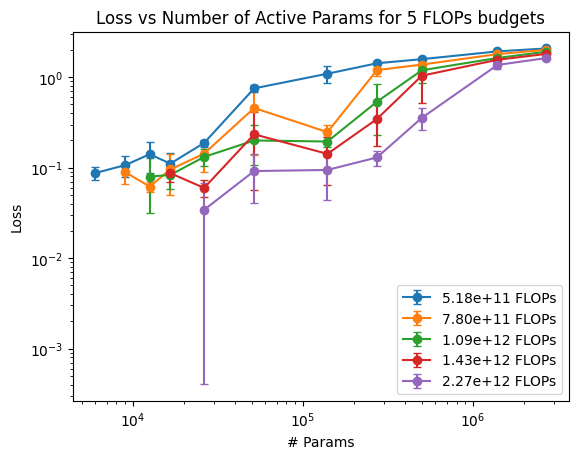

In [41]:
# epochs = np.arange(n_epochs)
param_counts = np.array(param_counts)

for FLOPs, eval_loss, eval_std, models in zip(FLOPs_budget, eval_losses, eval_stds, model_ranges):
    # plt.plot(param_counts[models[0]:models[1]+1], eval_loss, label=f"{FLOPs:.2e} FLOPs")
    plt.errorbar(
        param_counts[models[0]:models[1]+1],
        eval_loss,
        yerr=eval_std,
        marker='o',
        label = f"{FLOPs:.2e} FLOPs",
        capsize=3
    )

plt.ylabel("Loss")
plt.xlabel("# Params")
plt.xscale("log")
plt.yscale("log")
plt.title(f"Loss vs Number of Active Params for {len(FLOPs_budget)} FLOPs budgets")
plt.legend()
plt.show()

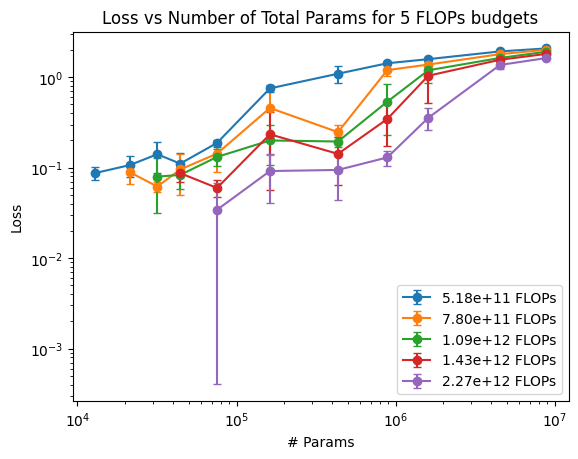

In [42]:
# epochs = np.arange(n_epochs)
param_counts = np.array(param_counts)

for FLOPs, eval_loss, eval_std, models in zip(FLOPs_budget, eval_losses, eval_stds, model_ranges):
    # plt.plot(param_counts[models[0]:models[1]+1], eval_loss, label=f"{FLOPs:.2e} FLOPs")
    plt.errorbar(
        total_param_counts[models[0]:models[1]+1],
        eval_loss,
        yerr=eval_std,
        marker='o',
        label = f"{FLOPs:.2e} FLOPs",
        capsize=3
    )

plt.ylabel("Loss")
plt.xlabel("# Params")
plt.xscale("log")
plt.yscale("log")
plt.title(f"Loss vs Number of Total Params for {len(FLOPs_budget)} FLOPs budgets")
plt.legend()
plt.show()

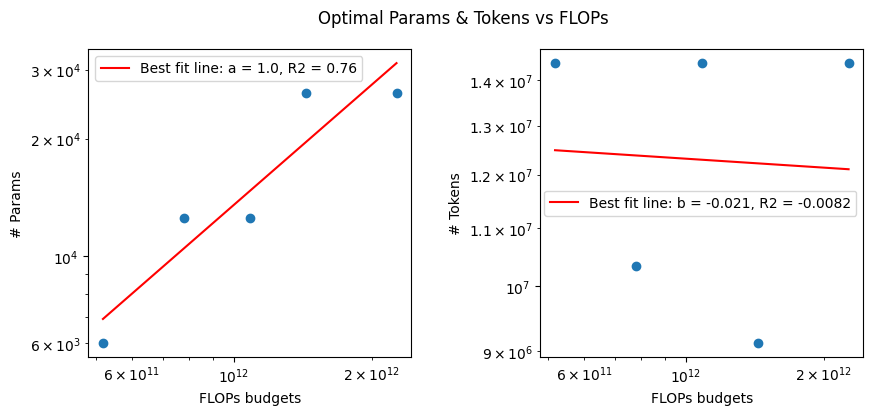

In [39]:
from sklearn.metrics import r2_score


min_params = []
min_toks = []

for i in range(len(eval_losses)): 
    idx = np.arange(model_ranges[i][0], model_ranges[i][1]+1)[np.argmin(eval_losses[i])]
    min_params.append(param_counts[idx])
    min_toks.append(FLOPs_budget[i] / (6.0 * param_counts[idx]))

coeffs_p = np.polyfit(np.log(FLOPs_budget), np.log(min_params), 1)
line_p = np.poly1d(coeffs_p)

coeffs_t = np.polyfit(np.log(FLOPs_budget), np.log(min_toks), 1)
line_t = np.poly1d(coeffs_t)

predicted_params = np.exp(line_p(np.log(FLOPs_budget)))
predicted_toks = np.exp(line_t(np.log(FLOPs_budget)))


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,4))
fig.subplots_adjust(wspace=0.4)

ax1.scatter(FLOPs_budget, min_params)
ax1.plot(FLOPs_budget, predicted_params, '-', c='red', label=f'Best fit line: a = {coeffs_p[0]:.2}, R2 = {r2_score(min_params, predicted_params):.2}')
ax1.set(ylabel="# Params", xlabel="FLOPs budgets")
ax1.set(xscale="log", yscale="log")
ax1.legend()

ax2.scatter(FLOPs_budget, min_toks)
ax2.plot(FLOPs_budget, predicted_toks, '-', c='red', label=f'Best fit line: b = {coeffs_t[0]:.2}, R2 = {r2_score(min_toks, predicted_toks):.2}')
ax2.set(ylabel="# Tokens", xlabel="FLOPs budgets")
ax2.set(xscale="log", yscale="log")
ax2.legend()

fig.suptitle("Optimal Params & Tokens vs FLOPs")
plt.show()